## Importing functions and utilities

In [9]:
# Importing required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import joblib # for saving the parameter of linear regression model
from pathlib import Path
from fracdiff.sklearn import Fracdiff
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from tqdm import tqdm 

import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.filterwarnings("ignore", category=InterpolationWarning)
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Importing functions from mypackage
from mypackage_utils import *


# Loading the updated time series

In [3]:
# Loading the dataset
sp500  = joblib.load("sp500_updated.pkl")
dax    = joblib.load("dax_updated.pkl")
nikkei = joblib.load("nikkei_updated.pkl")

# Forecasting 

In what follows, we are going to use linear regression and a shallow neural network to predict the return of the next-day. In particular we are also going to compare two different approaches: 
- one-step ahead, we want to predict the return of the next-day using the Close, Open, Low and High of the day before,
- sliding window, we want to predict the return of the next-day using  Close, Open, Low and High of the 5 day before.
In addition we want to compare how these different approaches and model behave while we use the differentiated time series and the fractional differentiated one.
After forecasting we are going to compare the result using the differnt kind of data using the RMSE (root mean squared error ) and MAE ( mean absolute error) as metrics.
In the end we want to see how the model behave if we use them for trading.

In [4]:
# Prepare dataseta for onest step ahead 

fd_cols   = ['Close_fd','Open_fd','High_fd','Low_fd']
diff_cols = ['Close_d','Open_d','High_d','Low_d']

# S&P 500 — fractional differentiation
train_sp500_fd, val_sp500_fd, test_sp500_fd, target_sp500_fd_tr, target_sp500_fd_val, target_sp500_fd_te = prepare_data(sp500, fd_cols)

# S&P 500 — integer differentation
train_sp500_d,  val_sp500_d,  test_sp500_d,  target_sp500_d_tr,  target_sp500_d_val,  target_sp500_d_te  = prepare_data(sp500, diff_cols)

# DAX — fractional
train_dax_fd, val_dax_fd, test_dax_fd, target_dax_fd_tr, target_dax_fd_val, target_dax_fd_te = prepare_data(dax, fd_cols)

# DAX — integer
train_dax_d,  val_dax_d,  test_dax_d,  target_dax_d_tr,  target_dax_d_val,  target_dax_d_te  = prepare_data(dax, diff_cols)

# Nikkei — fractional
train_nikkei_fd, val_nikkei_fd, test_nikkei_fd, target_nikkei_fd_tr, target_nikkei_fd_val, target_nikkei_fd_te = prepare_data(nikkei, fd_cols)

# Nikkei — integer
train_nikkei_d,  val_nikkei_d,  test_nikkei_d,  target_nikkei_d_tr,  target_nikkei_d_val,  target_nikkei_d_te  = prepare_data(nikkei, diff_cols)

In [5]:
# Prepare data using sliding window approach

window_size = 5
# S&P 500 — fractional 
train_sp500_fd_sw, val_sp500_fd_sw, test_sp500_fd_sw, target_sp500_fd_tr_sw, target_sp500_fd_val_sw, target_sp500_fd_te_sw = prepare_data_sw(sp500, fd_cols, window_size)	

# S&P 500 — integer 
train_sp500_d_sw, val_sp500_d_sw,  test_sp500_d_sw,  target_sp500_d_tr_sw,  target_sp500_d_val_sw,  target_sp500_d_te_sw  = prepare_data_sw(sp500, diff_cols, window_size)

# DAX — fractional 
train_dax_fd_sw, val_dax_fd_sw, test_dax_fd_sw, target_dax_fd_tr_sw, target_dax_fd_val_sw, target_dax_fd_te_sw = prepare_data_sw(dax, fd_cols, window_size)

# DAX — integer
train_dax_d_sw, val_dax_d_sw,  test_dax_d_sw,  target_dax_d_tr_sw,  target_dax_d_val_sw,  target_dax_d_te_sw  = prepare_data_sw(dax, diff_cols, window_size)

# Nikkei — fractional
train_nikkei_fd_sw, val_nikkei_fd_sw, test_nikkei_fd_sw, target_nikkei_fd_tr_sw, target_nikkei_fd_val_sw, target_nikkei_fd_te_sw = prepare_data_sw(nikkei, fd_cols, window_size)

# Nikkei — integer
train_nikkei_d_sw, val_nikkei_d_sw,  test_nikkei_d_sw,  target_nikkei_d_tr_sw,  target_nikkei_d_val_sw,  target_nikkei_d_te_sw  = prepare_data_sw(nikkei, diff_cols, window_size)

In [10]:
# Take the path of the folder to save the weights into that directory
weights_dir = Path("weights")

## Linear regression 
In the last part of this notebook we want to understand better how much does the fractional differentiation of the data helps us, indeed we try to do the one-step-ahead prediction and the sliding window one, using a simple linear regression.

## Linear regression one-step-ahead

In [12]:
# Linear regression one-step-ahead forecasting
results_l = {}
results_l["sp500_fd"]  = lin_reg(weights_dir / 'lin_reg_sp500_fd.pkl', train_sp500_fd, np.vstack((val_sp500_fd,test_sp500_fd)), target_sp500_fd_tr, np.vstack((target_sp500_fd_val,target_sp500_fd_te)) )
results_l["sp500_d"]   = lin_reg(weights_dir / 'lin_reg_sp500_d.pkl', train_sp500_d, np.vstack((val_sp500_d, test_sp500_d)),  target_sp500_d_tr,  np.vstack((target_sp500_d_val, target_sp500_d_te)) )

results_l["dax_fd"]    = lin_reg( weights_dir / 'lin_reg_dax_fd.pkl', train_dax_fd, np.vstack((val_dax_fd, test_dax_fd)), target_dax_fd_tr, np.vstack((target_dax_fd_val, target_dax_fd_te)) )
results_l["dax_d"]     = lin_reg( weights_dir / 'lin_reg_dax_d.pkl', train_dax_d, np.vstack((val_dax_d, test_dax_d)), target_dax_d_tr, np.vstack((target_dax_d_val, target_dax_d_te)) )

results_l["nikkei_fd"] = lin_reg( weights_dir / 'lin_reg_nikkei_fd.pkl', train_nikkei_fd, np.vstack((val_nikkei_fd, test_nikkei_fd)), target_nikkei_fd_tr, np.vstack((target_nikkei_fd_val, target_nikkei_fd_te)) )
results_l["nikkei_d"]  = lin_reg( weights_dir / 
'lin_reg_nikkei_d.pkl', train_nikkei_d, np.vstack((val_nikkei_d, test_nikkei_d)), target_nikkei_d_tr, np.vstack((target_nikkei_d_val, target_nikkei_d_te)) )

# Print results
for k, v in results_l.items():
    rmse, mae = v
    print(f"{k:10s} -> RMSE={rmse:.6f} | MAE={mae:.6f}")

sp500_fd   -> RMSE=0.014026 | MAE=0.007984
sp500_d    -> RMSE=0.013997 | MAE=0.007881
dax_fd     -> RMSE=0.013414 | MAE=0.008462
dax_d      -> RMSE=0.013422 | MAE=0.008441
nikkei_fd  -> RMSE=0.012423 | MAE=0.008344
nikkei_d   -> RMSE=0.012405 | MAE=0.008294


In [7]:
# Compare differetiated data vs fractionally differetiated data
for m in ["rmse","mae"]:
    df, avg = compare_models(results_l, metric=m, mode='no loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")


RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.013997         0.014026        -0.000029        -0.208822
   DAX      0.013422         0.013414         0.000009         0.063593
NIKKEI      0.012405         0.012423        -0.000018        -0.147976
AVERAGE  Δ=-0.000013   Δ%=-0.10% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.007881        0.007984        -0.000103        -1.304425
   DAX     0.008441        0.008462        -0.000021        -0.252819
NIKKEI     0.008294        0.008344        -0.000050        -0.599630
AVERAGE  Δ=-0.000058   Δ%=-0.72% 


## Linear Regression with sliding window

In [13]:
# Linear regression with sliding window approach
results_l_sw = {}
results_l_sw["sp500_fd"] = lin_reg( weights_dir / 'lin_reg_sp500_fd_sw.pkl', train_sp500_fd_sw, np.vstack((val_sp500_fd_sw,test_sp500_fd_sw)), target_sp500_fd_tr_sw, np.vstack((target_sp500_fd_val_sw,target_sp500_fd_te_sw)))
results_l_sw["sp500_d"]  = lin_reg( weights_dir / 'lin_reg_sp500_d_sw.pkl', train_sp500_d_sw, np.vstack((val_sp500_d_sw, test_sp500_d_sw)),  target_sp500_d_tr_sw,  np.vstack((target_sp500_d_val_sw, target_sp500_d_te_sw)) )

results_l_sw["dax_fd"]   = lin_reg( weights_dir / 'lin_reg_dax_fd_sw.pkl', train_dax_fd_sw, np.vstack((val_dax_fd_sw, test_dax_fd_sw)), target_dax_fd_tr_sw, np.vstack((target_dax_fd_val_sw, target_dax_fd_te_sw)) )
results_l_sw["dax_d"]    = lin_reg( weights_dir / 'lin_reg_dax_d_sw.pkl', train_dax_d_sw, np.vstack((val_dax_d_sw, test_dax_d_sw)), target_dax_d_tr_sw, np.vstack((target_dax_d_val_sw, target_dax_d_te_sw)) )

results_l_sw["nikkei_fd"] = lin_reg( weights_dir / 'lin_reg_nikkei_fd_sw.pkl', train_nikkei_fd_sw, np.vstack((val_nikkei_fd_sw, test_nikkei_fd_sw)), target_nikkei_fd_tr_sw, np.vstack((target_nikkei_fd_val_sw, target_nikkei_fd_te_sw)) )
results_l_sw["nikkei_d"]  = lin_reg( weights_dir / 'lin_reg_nikkei_d_sw.pkl', train_nikkei_d_sw, np.vstack((val_nikkei_d_sw, test_nikkei_d_sw)), target_nikkei_d_tr_sw, np.vstack((target_nikkei_d_val_sw, target_nikkei_d_te_sw)) )

# Print results
for k, v in results_l_sw.items():
    rmse, mae = v
    print(f"{k:10s} -> RMSE={rmse:.6f} | MAE={mae:.6f}")

sp500_fd   -> RMSE=0.014393 | MAE=0.008075
sp500_d    -> RMSE=0.014356 | MAE=0.008023
dax_fd     -> RMSE=0.013765 | MAE=0.008526
dax_d      -> RMSE=0.013969 | MAE=0.008567
nikkei_fd  -> RMSE=0.012581 | MAE=0.008505
nikkei_d   -> RMSE=0.012610 | MAE=0.008454


In [14]:
# Compare differetiated data vs fractionally differetiated data
for m in ["rmse","mae"]:
    df, avg = compare_models(results_l_sw, metric=m, mode='no loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")


RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.014356         0.014393        -0.000038        -0.261845
   DAX      0.013969         0.013765         0.000204         1.461190
NIKKEI      0.012610         0.012581         0.000030         0.234516
AVERAGE  Δ=0.000065   Δ%=0.48% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.008023        0.008075        -0.000052        -0.646889
   DAX     0.008567        0.008526         0.000041         0.476463
NIKKEI     0.008454        0.008505        -0.000050        -0.592856
AVERAGE  Δ=-0.000020   Δ%=-0.25% 


## ANN one-step-ahead

In what follows, we specify a shallow feed-forward neural network (one hidden layer) that takes the daily OHLC (Open, High, Low, Close) values of each index (already differentiaed and therefore stationary) as inputs and predicts the next-day closing price. The closing price of the next day has been taken as target.
This is a one-step-ahead forecasting setup. The rationale is that fractional differencing preserves long-memory features while improving stationarity, so past information is effectively embedded in the current inputs, making a one-step model appropriate.

100%|██████████| 500/500 [00:02<00:00, 191.67it/s, lr=0.001, train=9.7e-5, val=8e-5]      


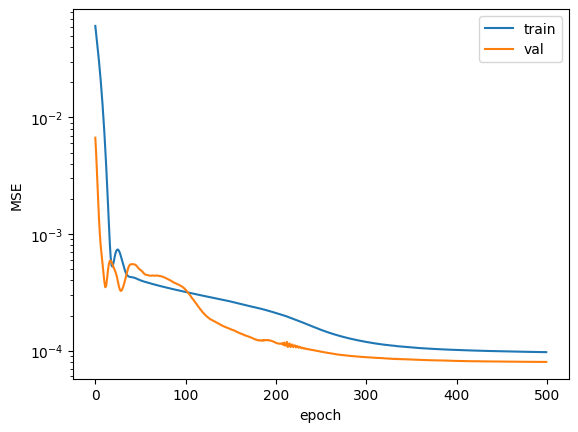

100%|██████████| 500/500 [00:02<00:00, 193.56it/s, lr=0.001, train=0.000134, val=0.00017] 


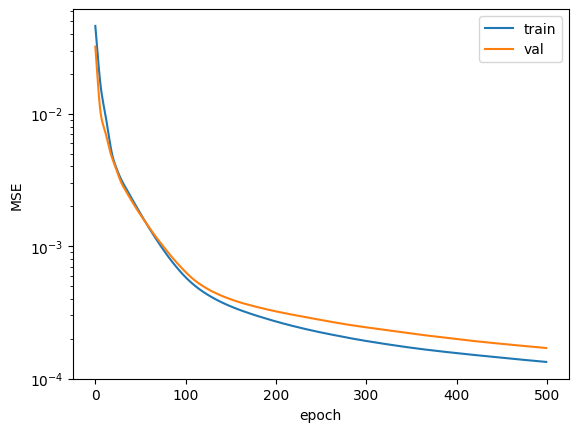

100%|██████████| 500/500 [00:02<00:00, 199.17it/s, lr=0.001, train=0.000168, val=8.47e-5] 


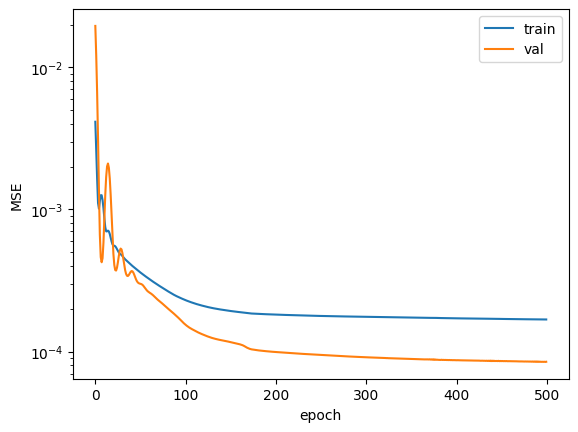

100%|██████████| 500/500 [00:02<00:00, 196.64it/s, lr=0.001, train=0.000247, val=0.00014] 


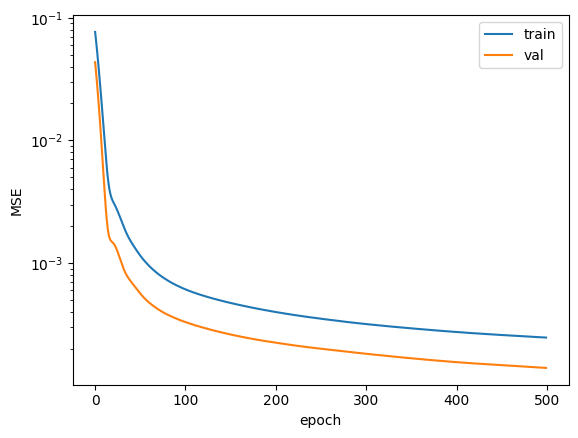

100%|██████████| 500/500 [00:02<00:00, 210.40it/s, lr=0.001, train=0.000203, val=0.000118]


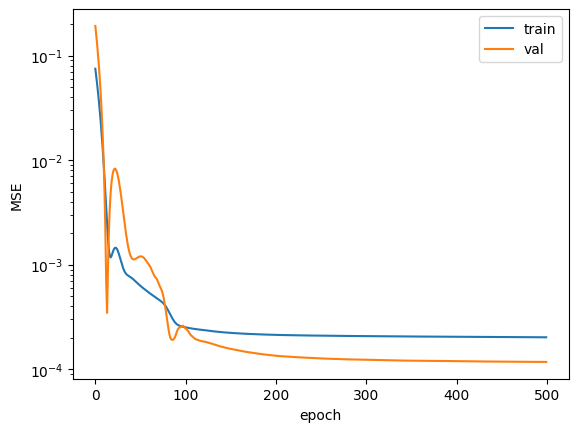

100%|██████████| 500/500 [00:02<00:00, 194.69it/s, lr=0.001, train=0.000285, val=0.000175]


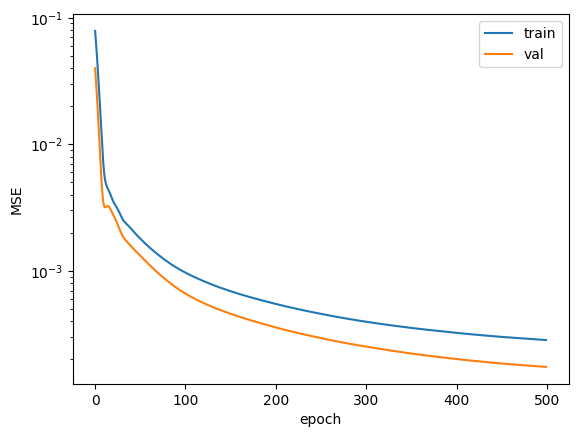

sp500_fd   -> Loss=0.000314 | RMSE=0.017725 | MAE=0.010805 
sp500_d    -> Loss=0.000496 | RMSE=0.022279 | MAE=0.013396 
dax_fd     -> Loss=0.000318 | RMSE=0.017831 | MAE=0.010909 
dax_d      -> Loss=0.000714 | RMSE=0.026727 | MAE=0.015452 
nikkei_fd  -> Loss=0.000238 | RMSE=0.015416 | MAE=0.010444 
nikkei_d   -> Loss=0.000312 | RMSE=0.017663 | MAE=0.012227 


In [15]:
# Train and evaluate
results_os = {}
results_os["sp500_fd"]  = train_evaluate(weights_dir / "nn_sp500_fd.weights.pth", train_sp500_fd, val_sp500_fd, test_sp500_fd, target_sp500_fd_tr, target_sp500_fd_val, target_sp500_fd_te, n_features=4)
results_os["sp500_d"]   = train_evaluate(weights_dir / "nn_sp500_d.weights.pth", train_sp500_d,  val_sp500_d,  test_sp500_d,  target_sp500_d_tr, target_sp500_d_val, target_sp500_d_te,  n_features=4)

results_os["dax_fd"]    = train_evaluate(weights_dir / "nn_dax_fd.weights.pth", train_dax_fd, val_dax_fd, test_dax_fd, target_dax_fd_tr, target_dax_fd_val, target_dax_fd_te, n_features=4)
results_os["dax_d"]     = train_evaluate(weights_dir / "nn_dax_d.weights.pth", train_dax_d,  val_dax_d,  test_dax_d,  target_dax_d_tr, target_dax_d_val, target_dax_d_te,  n_features=4)

results_os["nikkei_fd"] = train_evaluate(weights_dir / "nn_nikkei_fd.weights.pth", train_nikkei_fd, val_nikkei_fd, test_nikkei_fd, target_nikkei_fd_tr, target_nikkei_fd_val, target_nikkei_fd_te, n_features=4)
results_os["nikkei_d"]  = train_evaluate(weights_dir / "nn_nikkei_d.weights.pth", train_nikkei_d,  val_nikkei_d,  test_nikkei_d,  target_nikkei_d_tr, target_nikkei_d_val, target_nikkei_d_te,  n_features=4)

# Print results
for k, v in results_os.items():
    loss, rmse, mae = v
    print(f"{k:10s} -> Loss={loss:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f} ")

In [19]:
# Improvement of using fractional differetiation instead of integer differentiation
for m in ["loss","rmse","mae"]:
    df, avg = compare_models(results_os, metric=m, mode='loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")



LOSS
 index  loss_integer  loss_fractional  abs_improvement  pct_improvement
 SP500      0.000496         0.000314         0.000182        36.699905
   DAX      0.000714         0.000318         0.000396        55.488265
NIKKEI      0.000312         0.000238         0.000074        23.827743
AVERAGE  Δ=0.000218   Δ%=38.67% 

RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.022279         0.017725         0.004554        20.438643
   DAX      0.026727         0.017831         0.008895        33.282884
NIKKEI      0.017663         0.015416         0.002247        12.723281
AVERAGE  Δ=0.005232   Δ%=22.15% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.013396        0.010805         0.002591        19.340881
   DAX     0.015452        0.010909         0.004543        29.398831
NIKKEI     0.012227        0.010444         0.001783        14.581161
AVERAGE  Δ=0.002972   Δ%=21.11% 


In what follows, we compare differentiated data with fractionally differentiated data using an ANN with a sliding window. Instead of predicting tomorrow's log-closing price based on today's OHLC data, the input dataset consists of a frame of past data. 

The heuristic idea is that if fractional differentiation effectively preserves memory, there should be little difference between using today's features or a frame of past features. 

To further explore this, we also perform the same comparison using simple linear regression.

# ANN with sliding window

100%|██████████| 500/500 [00:02<00:00, 198.28it/s, lr=0.001, train=9.76e-5, val=0.000162] 


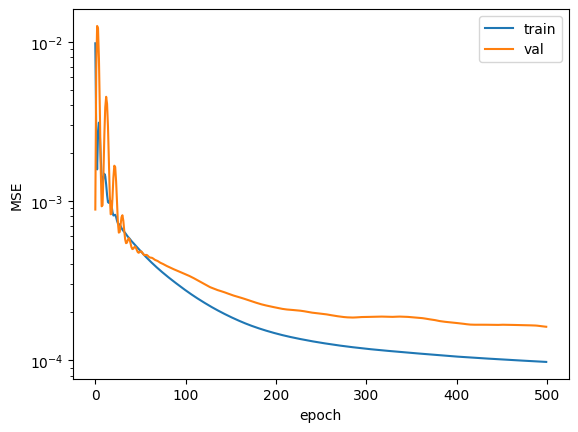

100%|██████████| 500/500 [00:02<00:00, 193.78it/s, lr=0.001, train=0.000102, val=0.000155]


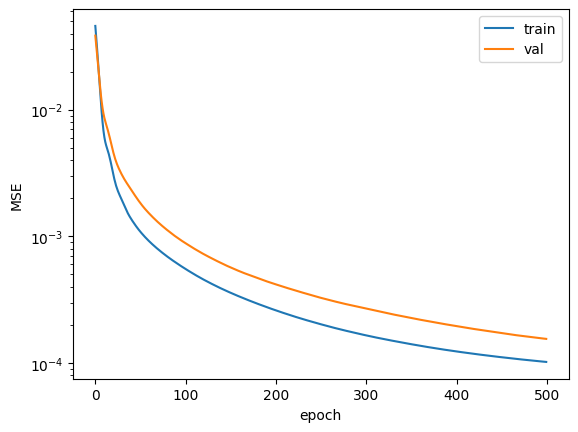

100%|██████████| 500/500 [00:02<00:00, 197.59it/s, lr=0.001, train=0.000211, val=8.2e-5]  


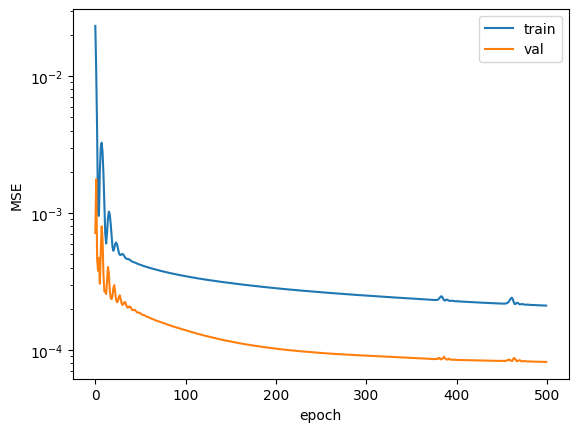

100%|██████████| 500/500 [00:02<00:00, 189.92it/s, lr=0.001, train=0.000161, val=0.000126]


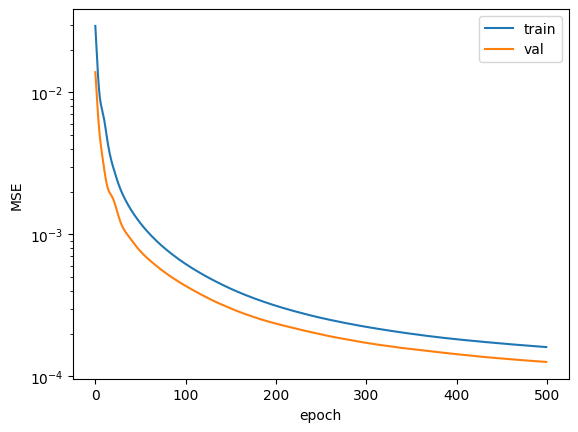

100%|██████████| 500/500 [00:02<00:00, 207.72it/s, lr=0.001, train=0.000219, val=0.000119]


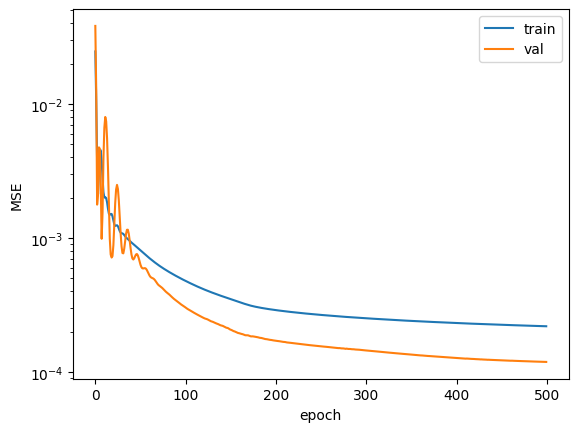

100%|██████████| 500/500 [00:02<00:00, 190.56it/s, lr=0.001, train=0.000225, val=0.000235]


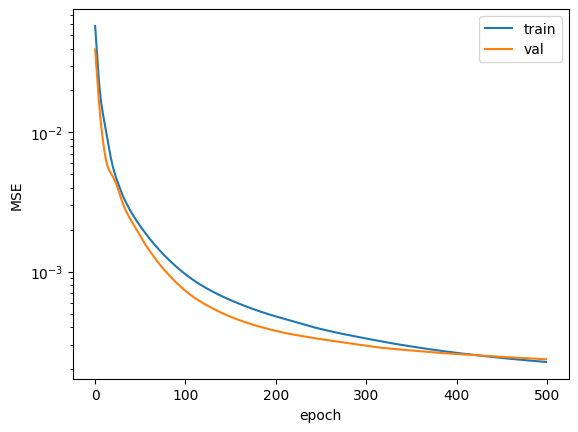

sp500_fd   -> Loss=0.000505 | RMSE=0.022463 | MAE=0.015436 
sp500_d    -> Loss=0.000721 | RMSE=0.026852 | MAE=0.016626 
dax_fd     -> Loss=0.000284 | RMSE=0.016862 | MAE=0.010722 
dax_d      -> Loss=0.000506 | RMSE=0.022499 | MAE=0.014168 
nikkei_fd  -> Loss=0.000260 | RMSE=0.016125 | MAE=0.010778 
nikkei_d   -> Loss=0.000461 | RMSE=0.021479 | MAE=0.014587 


In [16]:
# Train and evaluate 
results_sw = {}
results_sw["sp500_fd"]  = train_evaluate_sw(weights_dir / "nn_sp500_fd_sw.weights.pth", train_sp500_fd_sw, val_sp500_fd_sw, test_sp500_fd_sw, target_sp500_fd_tr_sw, target_sp500_fd_val_sw, target_sp500_fd_te_sw, n_features = window_size * 4)
results_sw["sp500_d"]   = train_evaluate_sw(weights_dir / "nn_sp500_d_sw.weights.pth", train_sp500_d_sw,  val_sp500_d_sw,  test_sp500_d_sw,  target_sp500_d_tr_sw,  target_sp500_d_val_sw,  target_sp500_d_te_sw,  n_features = window_size * 4)

results_sw["dax_fd"]    = train_evaluate_sw(weights_dir / "nn_dax_fd_sw.weights.pth", train_dax_fd_sw, val_dax_fd_sw, test_dax_fd_sw, target_dax_fd_tr_sw, target_dax_fd_val_sw, target_dax_fd_te_sw, n_features = window_size * 4)
results_sw["dax_d"]     = train_evaluate_sw(weights_dir / "nn_dax_d_sw.weights.pth", train_dax_d_sw,  val_dax_d_sw,  test_dax_d_sw,  target_dax_d_tr_sw,  target_dax_d_val_sw,  target_dax_d_te_sw,  n_features = window_size * 4)

results_sw["nikkei_fd"] = train_evaluate_sw(weights_dir / "nn_nikkei_fd_sw.weights.pth", train_nikkei_fd_sw, val_nikkei_fd_sw, test_nikkei_fd_sw, target_nikkei_fd_tr_sw, target_nikkei_fd_val_sw, target_nikkei_fd_te_sw, n_features = window_size * 4)
results_sw["nikkei_d"]  = train_evaluate_sw(weights_dir / "nn_nikkei_d_sw.weights.pth", train_nikkei_d_sw,  val_nikkei_d_sw,  test_nikkei_d_sw,  target_nikkei_d_tr_sw,  target_nikkei_d_val_sw,  target_nikkei_d_te_sw,  n_features = window_size * 4)

# Print results
for k, v in results_sw.items():
    loss, rmse, mae = v
    print(f"{k:10s} -> Loss={loss:.6f} | RMSE={rmse:.6f} | MAE={mae:.6f} ")


In [17]:
# Improvement of using fractional differetiation instead of integer differentiation
for m in ["loss","rmse","mae"]:
    df, avg = compare_models(results_sw, metric=m, mode='loss')
    print("\n" + m.upper())
    print(df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"AVERAGE  Δ={avg['abs_improvement']:.6f}   Δ%={avg['pct_improvement']:.2f}% ")



LOSS
 index  loss_integer  loss_fractional  abs_improvement  pct_improvement
 SP500      0.000721         0.000505         0.000216        30.018437
   DAX      0.000506         0.000284         0.000222        43.831370
NIKKEI      0.000461         0.000260         0.000201        43.640518
AVERAGE  Δ=0.000213   Δ%=39.16% 

RMSE
 index  rmse_integer  rmse_fractional  abs_improvement  pct_improvement
 SP500      0.026852         0.022463         0.004389        16.345016
   DAX      0.022499         0.016862         0.005637        25.054266
NIKKEI      0.021479         0.016125         0.005354        24.927048
AVERAGE  Δ=0.005127   Δ%=22.11% 

MAE
 index  mae_integer  mae_fractional  abs_improvement  pct_improvement
 SP500     0.016626        0.015436         0.001190         7.157308
   DAX     0.014168        0.010722         0.003446        24.321433
NIKKEI     0.014587        0.010778         0.003809        26.109737
AVERAGE  Δ=0.002815   Δ%=19.20% 


## 💹 Using the trained model as a trading signal

We now want to see how the model performs when used for **trading decisions** rather than pure prediction.
In particular, we’ll check whether the **fractionally differenced model** provides a better trading signal than the **integer-differenced** one.

**Trading logic (single-unit strategy):**

* For each day in the **test set**, the model predicts tomorrow’s log-closing price.
* If the **predicted price for tomorrow** is **higher than today’s closing price**, we take a **long position** (buy one unit).
* Otherwise, we take a **short position** (sell one unit).
* The position is closed at the next day’s close, and the process repeats for the entire test period.

**Evaluation setup:**

* We use the usual **chronological split**, where roughly **33% of all days** form the **testing set**.
* This proportional split ensures comparability across markets that may have **different trading calendars**. 🌍


In [18]:

results_sp500 = {}
# S&P 500
results_sp500["nn_fd_os"]  = trading_signal_strategy(sp500, test_sp500_fd,  weights_dir / "nn_sp500_fd.weights.pth",  mode="fractional", n_features=4, model="neural_network")
results_sp500["nn_d_os"]   = trading_signal_strategy(sp500, test_sp500_d,   weights_dir / "nn_sp500_d.weights.pth",   mode="integer",    n_features=4, model="neural_network")
results_sp500["lr_fd_os"]  = trading_signal_strategy(sp500, test_sp500_fd,  weights_dir / "lin_reg_sp500_fd.pkl",  mode="fractional", n_features=4, model="linear_regression")
results_sp500["lr_d_os"]   = trading_signal_strategy(sp500, test_sp500_d,   weights_dir / "lin_reg_sp500_d.pkl",   mode="integer",    n_features=4, model="linear_regression")
results_sp500["nn_fd_sw"]  = trading_signal_strategy(sp500, test_sp500_fd_sw,  weights_dir / "nn_sp500_fd_sw.weights.pth",  mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_sp500["nn_d_sw"]   = trading_signal_strategy(sp500, test_sp500_d_sw,  weights_dir / "nn_sp500_d_sw.weights.pth",   mode="sliding_window",    n_features=window_size * 4, model="neural_network")
results_sp500["lr_fd_sw"]  = trading_signal_strategy(sp500, test_sp500_fd_sw, weights_dir / "lin_reg_sp500_fd_sw.pkl",  mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_sp500["lr_d_sw"]   = trading_signal_strategy(sp500, test_sp500_d_sw,  weights_dir / "lin_reg_sp500_d_sw.pkl",   mode="sliding_window",    n_features=window_size * 4, model="linear_regression")

results_dax = {}
# DAX
results_dax["nn_fd_os"]    = trading_signal_strategy(dax,   test_dax_fd,    weights_dir / "nn_dax_fd.weights.pth",    mode="fractional", n_features=4, model="neural_network")
results_dax["nn_d_os"]     = trading_signal_strategy(dax,   test_dax_d,     weights_dir / "nn_dax_d.weights.pth",     mode="integer",    n_features=4, model="neural_network")
results_dax["lr_fd_os"]    = trading_signal_strategy(dax,   test_dax_fd,    weights_dir / "lin_reg_dax_fd.pkl",    mode="fractional", n_features=4, model="linear_regression")
results_dax["lr_d_os"]     = trading_signal_strategy(dax,   test_dax_d,    weights_dir / "lin_reg_dax_d.pkl",     mode="integer",    n_features=4, model="linear_regression")
results_dax["nn_fd_sw"] = trading_signal_strategy(dax,   test_dax_fd_sw,   weights_dir / "nn_dax_fd_sw.weights.pth", mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_dax["nn_d_sw"] = trading_signal_strategy(dax,   test_dax_d_sw,     weights_dir / "nn_dax_d_sw.weights.pth",  mode="sliding_window",    n_features=window_size * 4, model="neural_network")
results_dax["lr_fd_sw"] = trading_signal_strategy(dax,   test_dax_fd_sw,   weights_dir / "lin_reg_dax_fd_sw.pkl",  mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_dax["lr_d_sw"] = trading_signal_strategy(dax,   test_dax_d_sw,     weights_dir / "lin_reg_dax_d_sw.pkl",  mode="sliding_window",    n_features=window_size * 4, model="linear_regression")

results_nikkei = {}
# Nikkei
results_nikkei["nn_fd_os"] = trading_signal_strategy(nikkei, test_nikkei_fd, weights_dir / "nn_nikkei_fd.weights.pth", mode="fractional", n_features=4, model="neural_network")
results_nikkei["nn_d_os"]  = trading_signal_strategy(nikkei, test_nikkei_d,  weights_dir / "nn_nikkei_d.weights.pth",  mode="integer",    n_features=4, model="neural_network")
results_nikkei["lr_fd_os"] = trading_signal_strategy(nikkei, test_nikkei_fd, weights_dir / "lin_reg_nikkei_fd.pkl", mode="fractional", n_features=4, model="linear_regression")
results_nikkei["lr_d_os"]  = trading_signal_strategy(nikkei, test_nikkei_d,  weights_dir / "lin_reg_nikkei_d.pkl",  mode="integer",    n_features=4, model="linear_regression")
results_nikkei["nn_fd_sw"] = trading_signal_strategy(nikkei, test_nikkei_fd_sw, weights_dir / "nn_nikkei_fd_sw.weights.pth",mode="sliding_window", n_features=window_size * 4, model="neural_network")
results_nikkei["nn_d_sw"]  = trading_signal_strategy(nikkei, test_nikkei_d_sw,  weights_dir / "nn_nikkei_d_sw.weights.pth", mode="sliding_window",    n_features=window_size * 4, model="neural_network")
results_nikkei["lr_fd_sw"] = trading_signal_strategy(nikkei, test_nikkei_fd_sw, weights_dir / "lin_reg_nikkei_fd_sw.pkl", mode="sliding_window", n_features=window_size * 4, model="linear_regression")
results_nikkei["lr_d_sw"]  = trading_signal_strategy(nikkei, test_nikkei_d_sw,  weights_dir / "lin_reg_nikkei_d_sw.pkl", mode="sliding_window",  n_features=window_size * 4, model="linear_regression")


## Cumulative Returns for different strategies 

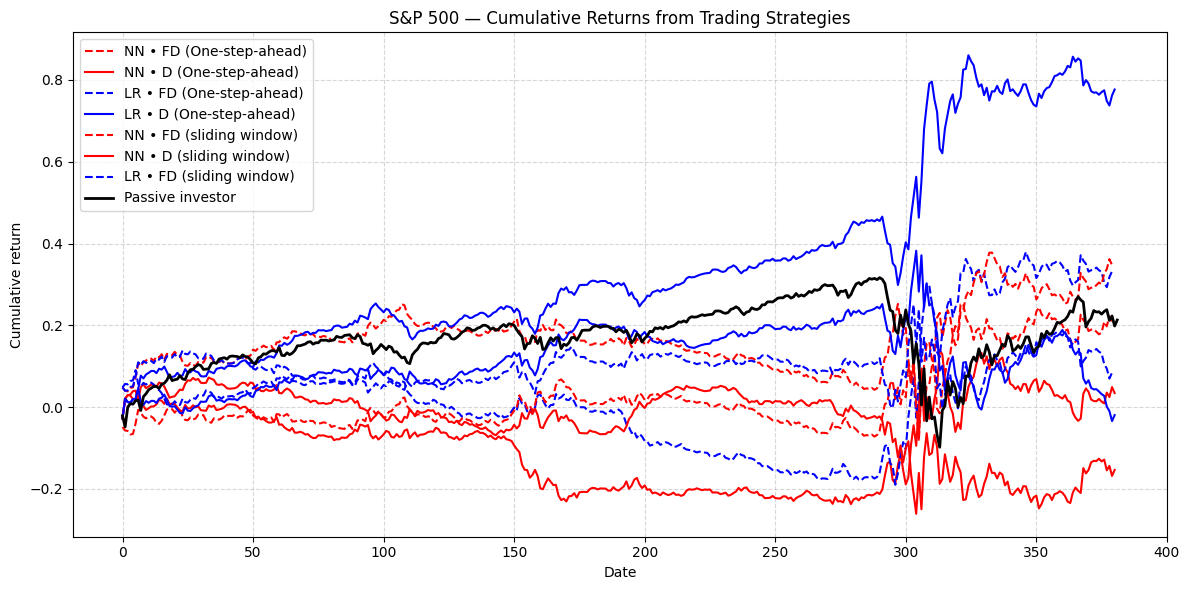

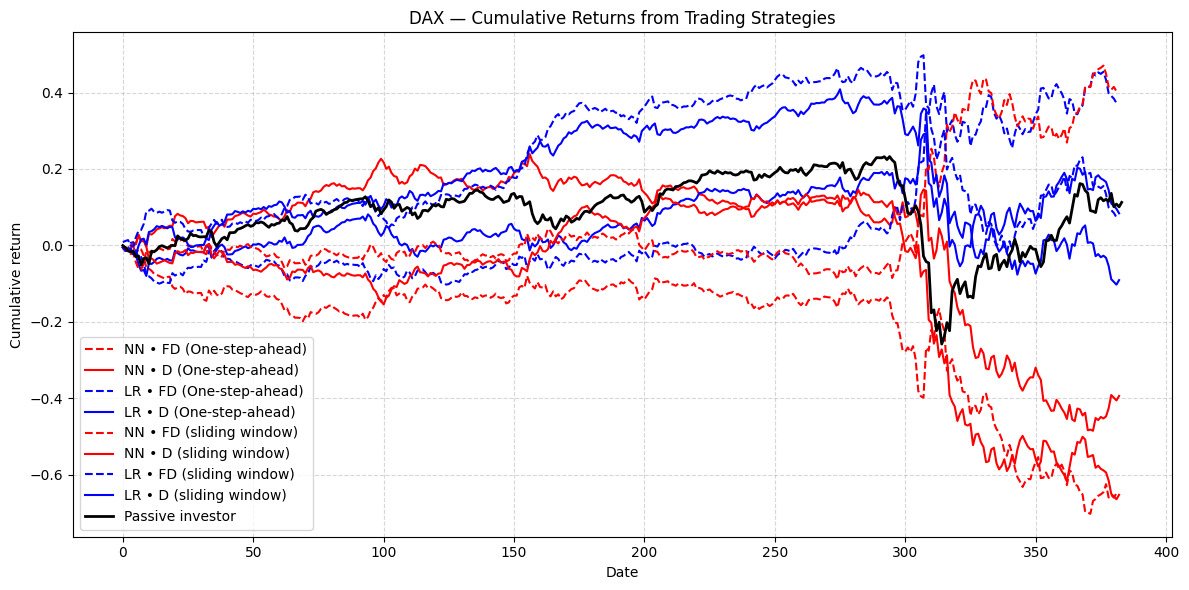

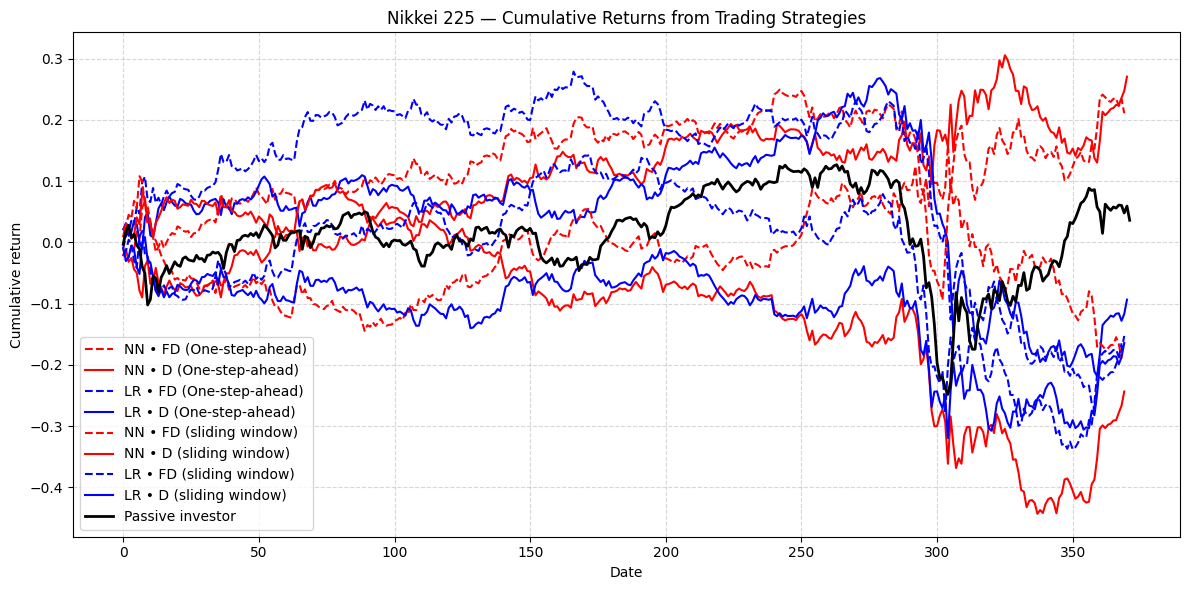

In [19]:
for series_name, results in {
	"S&P 500 — ": results_sp500,
	"DAX — ": results_dax,
	"Nikkei 225 — ": results_nikkei,
}.items():
	plot_results_trading_strategy(results, series_name, sp500 if "S&P 500" in series_name else dax if "DAX" in series_name else nikkei)